# metrics-simulation

Feedback loop for testing Graphite alert queries against synthetic time series scenarios.

**Workflow:**
1. Define scenarios (what shapes can this metric take?)
2. Define your alert rule — paste the Graphite query from Grafana
3. Run the simulation
4. Review the summary table and plots
5. Adjust the query and re-run from step 3

In [1]:
import numpy as np
from metrics_simulation import (
    AlertRule, MonteCarloResult,
    simulate, summary, plot_results,
    monte_carlo, mc_summary, plot_monte_carlo,
    scenarios, GraphiteServer,
)

## Graphite server

Start a fresh Graphite container managed by Python.
Call `server.reset()` at any point to wipe all stored metrics and start clean.

In [2]:
server = GraphiteServer()
server.start()

## Step 1: Define scenarios

Each scenario models a different real-world situation for the same metric.
Fix the RNG seed for reproducibility, or remove it for fresh noise each run.

In [3]:
rng = np.random.default_rng(seed=42)

my_scenarios = [
    scenarios.baseline(duration_min=120, rate=0.02, rng=rng),
    scenarios.spike(duration_min=120, spike_at_min=60, spike_value=1.0, rng=rng),
    scenarios.gradual_creep(duration_min=120, creep_start_min=60, end_rate=0.15, rng=rng, phi=1),
    scenarios.zero_drop(duration_min=120, drop_at_min=60, rng=rng),
]

## Step 2: Define your alert rule

Paste the Graphite expression from Grafana into `query`.
Use `{metric}` as a placeholder — it gets substituted with each scenario's metric path at evaluation time.

Example expressions:
- `{metric}` — raw metric, no transformation
- `movingAverage({metric}, 5)` — 5-point moving average
- `summarize({metric}, '5min', 'avg')` — 5-minute bucket average

In [4]:
rule = AlertRule(
    query="{metric}",
    threshold=0.05,
    comparator="gt",
    for_duration_points=1,
)

## Step 3: Run the simulation

Writes each scenario to Graphite, waits briefly for the write to flush, then evaluates the query via the Graphite render API.

In [5]:
results = simulate(rule, my_scenarios, server=server)

## Step 4: Review results

The summary table shows at a glance which scenarios fired and when.
The plot shows the raw data, query output, threshold, and firing windows for each scenario.

In [6]:
summary(results)

,scenario,description,fired,first_fire_min
0,baseline,Stable ~2% error rate. Alert should not fire.,False,NaN
1,spike,Single-point 100% error rate at minute 60. Tes...,False,NaN
2,gradual_creep,Error rate rises from 2% to 15% starting at mi...,True,75.85
3,zero_drop,Error rate (and likely traffic) drops to 0 at ...,False,NaN


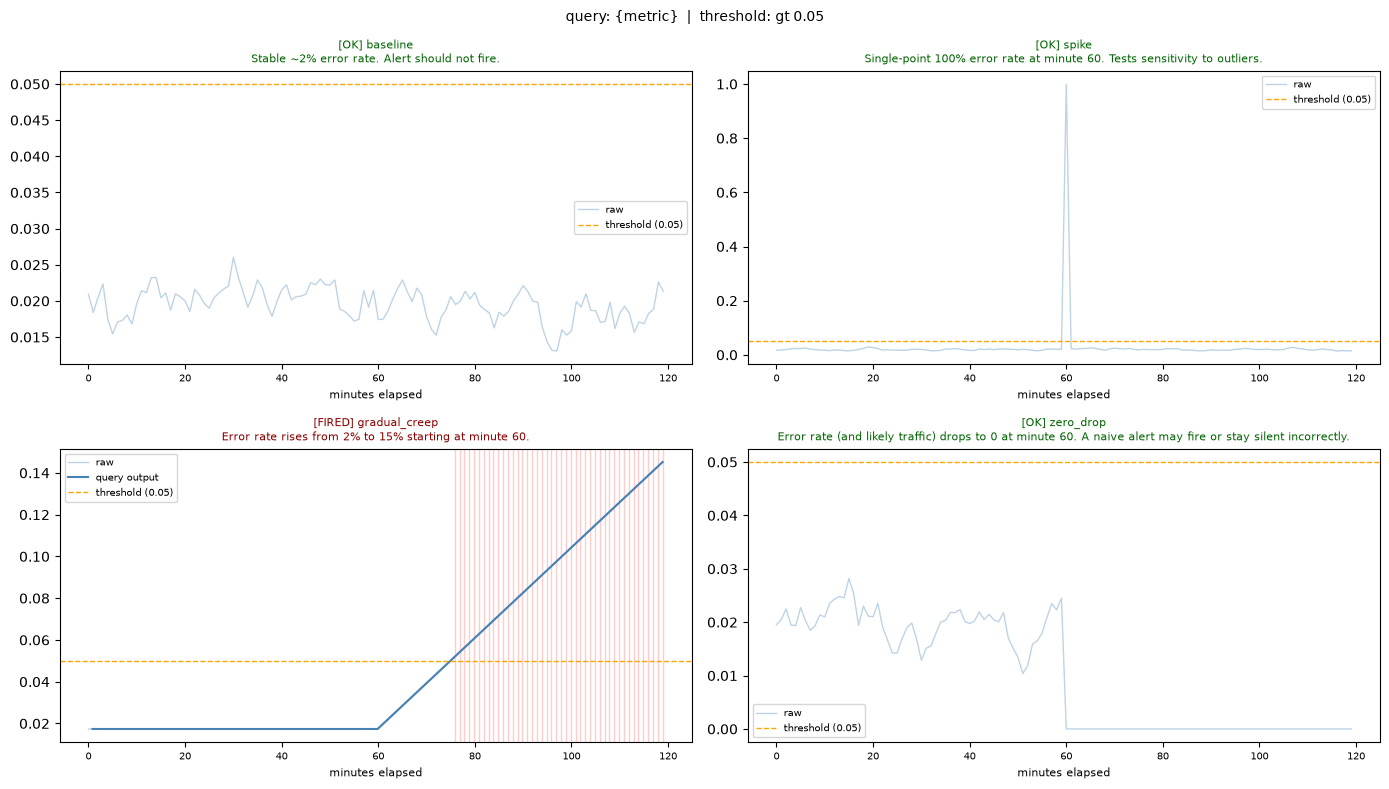

In [7]:
plot_results(results, rule)

---
## Monte Carlo simulation - Example using static threshold alert

Instead of a single run per scenario, Monte Carlo runs each scenario N times with different
noise seeds and reports the *firing rate* across runs.

This answers questions like:
- Does this alert fire on 5% of normal runs? (false positive rate)
- Does it fire on 90% of spike runs? (true positive rate)

Define factories — callables that accept an `rng` and return a `Scenario`.
These are the same generator functions as above, just wrapped so each run gets fresh noise.

In [8]:
factories = [
    lambda rng: scenarios.baseline(duration_min=120, rate=0.02, rng=rng),
    lambda rng: scenarios.spike(duration_min=120, spike_at_min=60, spike_value=1.0, rng=rng),
    lambda rng: scenarios.gradual_creep(duration_min=120, creep_start_min=60, end_rate=0.15, rng=rng),
    lambda rng: scenarios.zero_drop(duration_min=120, drop_at_min=60, rng=rng),
]

In [9]:
mc_results = monte_carlo(
    rule,
    factories,
    server=server,
    n=100,
    seed=42,
)

In [10]:
mc_summary(mc_results)

,scenario,n_runs,fire_rate,median_first_fire_min
0,baseline,100,0.0,NaN
1,spike,100,1.0,59.933333
2,gradual_creep,100,1.0,73.933333
3,zero_drop,100,0.0,NaN


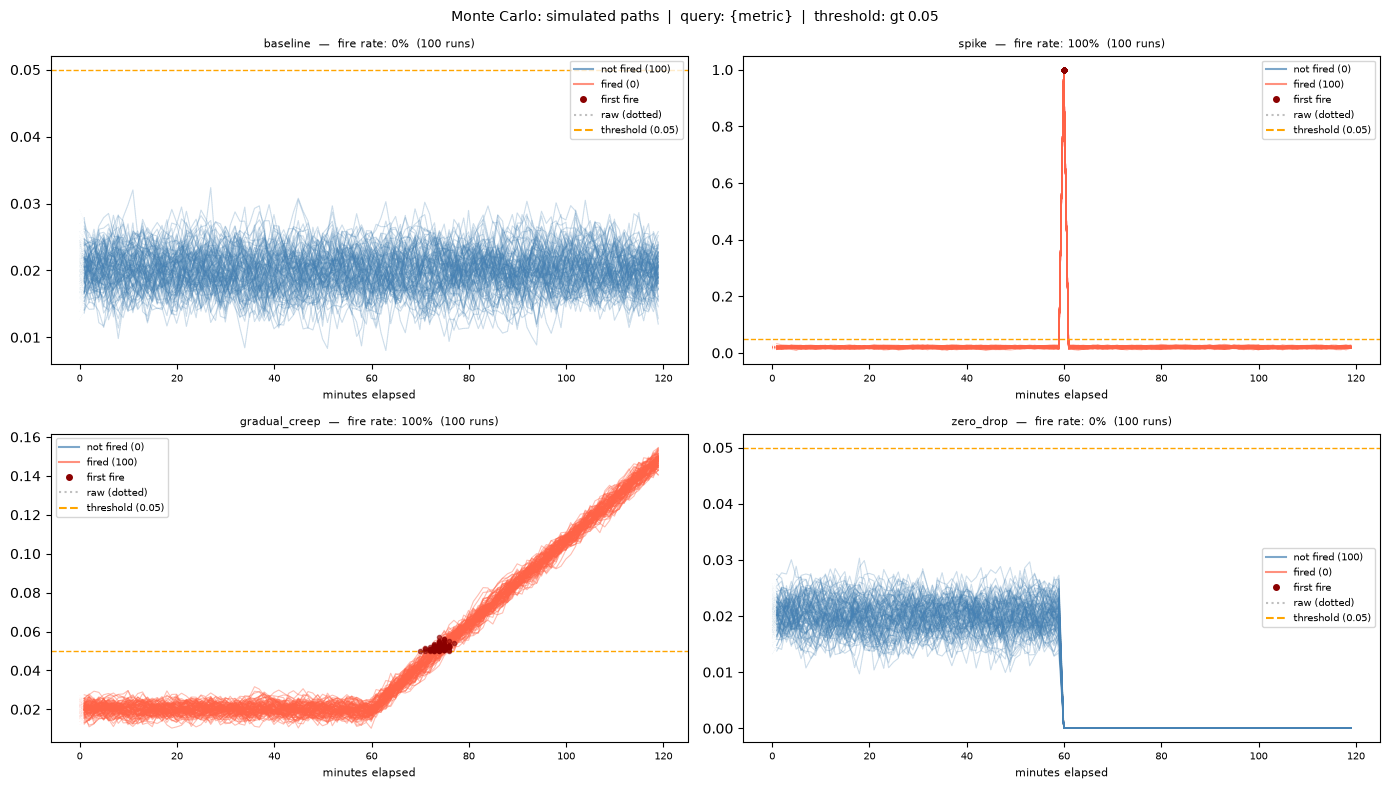

In [11]:
plot_monte_carlo(mc_results, rule)